In [1]:
# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:

# Step 2: Load Dataset
df = pd.read_csv("/kaggle/input/datasets/jamaltariqcheema/pima-indians-diabetes-dataset/diabetes.csv")

print("First 5 rows:")
print(df.head())



First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [3]:
# Step 3: Data Preprocessing
# Replace 0 values with median (for columns where 0 is invalid)
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in cols:
    df[col] = df[col].replace(0, df[col].median())



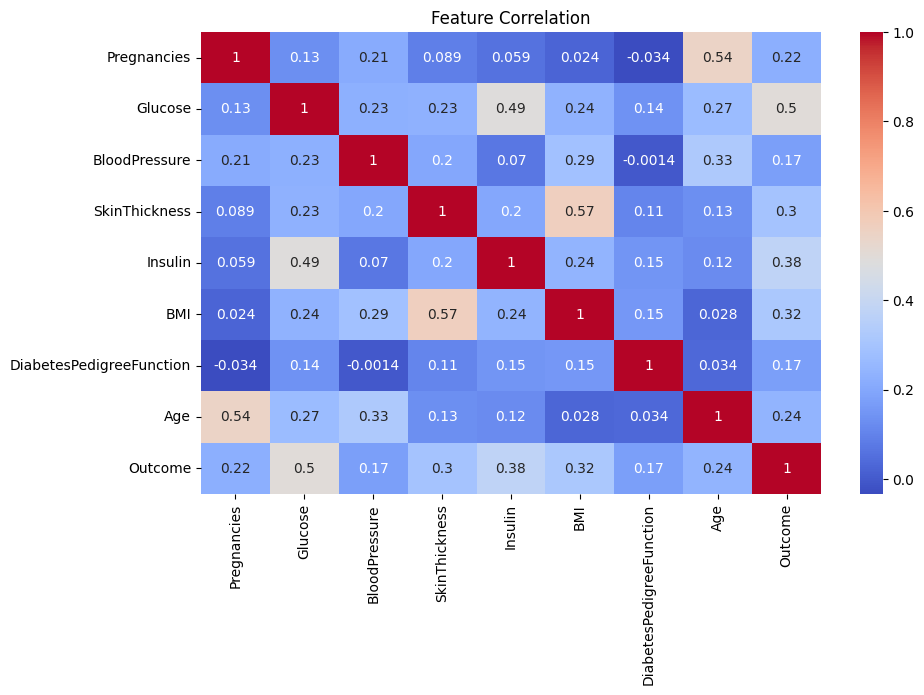

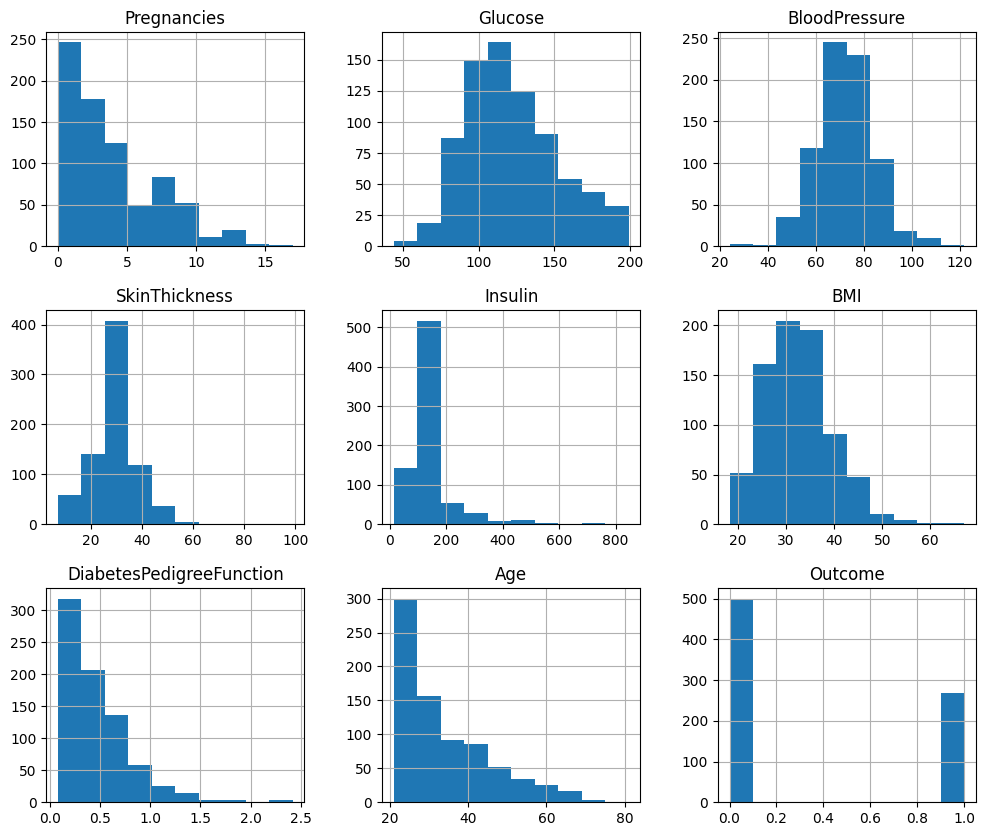

In [4]:
# Step 4: Exploratory Data Analysis
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

# Distribution
df.hist(figsize=(12,10))
plt.show()



In [5]:
# Step 5: Split Data
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [6]:

# Step 6: Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 7: Model Training
model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

Accuracy: 0.7727272727272727

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.84      0.83        99
           1       0.69      0.65      0.67        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



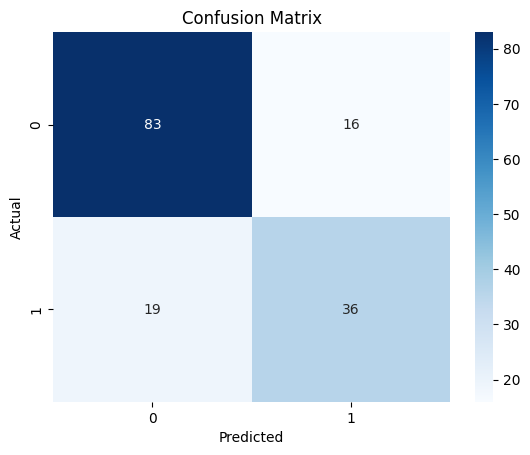

In [7]:

# Step 8: Predictions
y_pred = model.predict(X_test)

# Step 9: Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### High Accuracy Pipeline

In [9]:
# Advanced Diabetes Prediction Pipeline

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.impute import KNNImputer

# Optional (install xgboost if not installed)
from xgboost import XGBClassifier

# Load dataset
df = pd.read_csv("/kaggle/input/datasets/jamaltariqcheema/pima-indians-diabetes-dataset/diabetes.csv")

# ---------------------------
# 1. Smart Preprocessing
# ---------------------------

# Replace invalid zeros with NaN
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[cols] = df[cols].replace(0, np.nan)

# KNN Imputation (better than median)
imputer = KNNImputer(n_neighbors=5)
df[cols] = imputer.fit_transform(df[cols])

# ---------------------------
# 2. Feature Engineering
# ---------------------------

# Create new features
df["BMI_Age"] = df["BMI"] * df["Age"]
df["Glucose_Insulin"] = df["Glucose"] * df["Insulin"]

# Split
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ---------------------------
# 3. Models
# ---------------------------

rf = RandomForestClassifier()
gb = GradientBoostingClassifier()
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# ---------------------------
# 4. Hyperparameter Tuning
# ---------------------------

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
}

rf_grid = GridSearchCV(rf, rf_params, cv=5)
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

# ---------------------------
# 5. Ensemble Model
# ---------------------------

ensemble = VotingClassifier(
    estimators=[
        ("rf", best_rf),
        ("gb", gb),
        ("xgb", xgb)
    ],
    voting='soft'
)

ensemble.fit(X_train, y_train)

# ---------------------------
# 6. Evaluation
# ---------------------------

y_pred = ensemble.predict(X_test)

print("Final Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Final Accuracy: 0.8961038961038961

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.92      0.92       100
           1       0.85      0.85      0.85        54

    accuracy                           0.90       154
   macro avg       0.89      0.89      0.89       154
weighted avg       0.90      0.90      0.90       154



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:12:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
